In [1]:
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import pandas as pd

import re

In [2]:
#load in just the crossed Data set
df3 = pd.read_csv("/home/wenyuantong/Desktop/data/all_cross/50_99.csv", index_col=0)
df3.head()

,HopX1a_N-terminal_1_88,HopX1a_C-terminal_298_380,HopX1c_N-terminal_1_87,HopX1c_Middle_212_267,HopX1b_N-terminal_1_74,HopX1g_N-terminal_1_68,HopBO1c_N-terminal_1_57,HopBO1c_Middle_112_205,HopBO1b_N-terminal_1_59,HopBO1b_Middle_105_171,...,Q944Q0_middle_280_334,Q944Q0_middle_425_509,Q94AU3_N-terminal_1_65,Q9ATB4_middle_181_246,Q9ATB4_middle_365_416,Q9C6K4_N-terminal_1_82,Q9C6K4_middle_209_305,Q9C9I4_N-terminal_1_56,Q9LF48_C-terminal_101_175,Q9LXF4_N-terminal_1_79
HopX1a_N-terminal_1_88,3.516703,3.409540,3.072912,0.527976,3.034622,2.831076,2.075563,1.840887,2.084241,1.373931,...,1.775923,1.255023,1.268221,1.336127,0.825495,1.618738,0.813058,1.874163,5.366706,2.702283
HopX1a_C-terminal_298_380,3.614934,3.070338,3.133250,0.394827,3.060764,2.543756,2.101262,1.292691,2.233731,1.243716,...,1.688731,1.362504,1.521192,1.243997,0.938525,1.741289,0.784720,1.152420,5.394567,2.956477
HopX1c_N-terminal_1_87,3.108233,2.989193,2.715768,0.178095,2.704708,2.539902,1.795120,1.351725,1.776713,1.001231,...,1.451790,0.712826,0.903910,0.908437,0.513998,1.100584,0.111875,1.569019,4.963816,2.243116
HopX1c_Middle_212_267,0.829676,0.585189,0.276683,2.636544,0.187466,1.597532,0.544271,3.667013,0.561779,0.975897,...,2.056686,2.902367,-2.632039,1.561512,0.118954,0.793149,3.275426,6.833592,-1.223650,0.353522
HopX1b_N-terminal_1_74,3.608739,3.433020,3.179860,0.141867,3.130227,2.781789,2.099485,1.418330,2.093578,1.249201,...,1.587612,0.859712,1.606587,1.037678,0.746984,1.435214,0.277455,1.082236,5.672187,2.762363


In [3]:
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
	
# Set such that PDF fonts export in a manner that they
# are editable in illustrator/affinity
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# set to define axes linewidths
matplotlib.rcParams['axes.linewidth'] = 0.5

# this defines some prefactors so inline figures look nice
# on a retina macbook. These can be commented out without any
# issue and are solely asthetic.
%matplotlib inline
%config InlineBackend.figure_format='retina'

font = {'family' : 'sans-serif',
    	'weight' : 'normal'}

matplotlib.rc('font', **font)

from tqdm import tqdm
import pickle
from sparrow import Protein
import protfasta
from tqdm.auto import tqdm

In [3]:
from shephard.apis import uniprot
from shephard.interfaces import si_domains, si_protein_attributes

from finches import Mpipi_frontend, CALVADOS_frontend
mf = Mpipi_frontend()
cf = CALVADOS_frontend()

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/finches/forcefields/calvados.py:236: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.038286503882254706' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  r.loc['H','q'] = 1. / ( 1 + 10**(self.pH-6) )


In [4]:
mode='mpipi'

In [6]:

df_numbered_indices = df3.copy()
df_numbered_indices.index = range(len(df3.index)) # Assign new numerical row index
df_numbered_indices.columns = range(len(df3.columns)) # Assign new numerical column index

print("\nNew DataFrame with numerical indices:")
display(df_numbered_indices)


New DataFrame with numerical indices:


,0,1,2,3,4,5,6,7,8,9,...,9135,9136,9137,9138,9139,9140,9141,9142,9143,9144
0,3.516703,3.409540,3.072912,0.527976,3.034622,2.831076,2.075563,1.840887,2.084241,1.373931,...,1.775923,1.255023,1.268221,1.336127,0.825495,1.618738,0.813058,1.874163,5.366706,2.702283
1,3.614934,3.070338,3.133250,0.394827,3.060764,2.543756,2.101262,1.292691,2.233731,1.243716,...,1.688731,1.362504,1.521192,1.243997,0.938525,1.741289,0.784720,1.152420,5.394567,2.956477
2,3.108233,2.989193,2.715768,0.178095,2.704708,2.539902,1.795120,1.351725,1.776713,1.001231,...,1.451790,0.712826,0.903910,0.908437,0.513998,1.100584,0.111875,1.569019,4.963816,2.243116
3,0.829676,0.585189,0.276683,2.636544,0.187466,1.597532,0.544271,3.667013,0.561779,0.975897,...,2.056686,2.902367,-2.632039,1.561512,0.118954,0.793149,3.275426,6.833592,-1.223650,0.353522
4,3.608739,3.433020,3.179860,0.141867,3.130227,2.781789,2.099485,1.418330,2.093578,1.249201,...,1.587612,0.859712,1.606587,1.037678,0.746984,1.435214,0.277455,1.082236,5.672187,2.762363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9140,1.737182,1.762525,1.167693,0.541663,1.295193,1.689674,1.023432,1.540548,0.973858,0.729068,...,1.241420,0.799707,-0.091270,0.519988,0.099345,0.395845,0.625880,2.252113,2.361811,1.308275
9141,0.737620,0.671461,0.100342,1.890968,0.211667,1.376144,0.521730,2.946455,0.401660,0.936013,...,1.746685,2.066915,-1.737705,0.985738,-0.011420,0.529094,2.743371,5.032035,-0.613257,0.383116
9142,2.945113,1.708051,2.437583,6.833592,1.430098,4.154420,2.099175,9.779824,2.139615,3.396088,...,4.770994,7.970247,-3.101902,4.394550,1.481059,3.297738,8.716204,13.855721,-4.036586,1.875832
9143,6.296935,5.969988,5.758026,-0.913659,5.596558,4.046560,3.683935,0.796913,3.724667,2.091918,...,1.863122,0.452930,5.711860,1.226828,1.754637,2.582247,-0.793146,-3.013984,10.583458,5.701903


In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list,fcluster
import matplotlib.patches as mpatches

In [5]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

In [8]:
df = df_numbered_indices

In [10]:
max_n_clusters = 25

In [13]:
spectral_results = []

# Note: SpectralClustering can be computationally intensive for large datasets or many features.
# You might consider downsampling or reducing feature dimensionality if it runs too slow.
# Also, it expects input data, not distance matrix directly.

for n_clusters in range(2, max_n_clusters):
    # Using 'rbf' kernel as a common choice. Adjust if your data suggests otherwise.
    spectral = SpectralClustering(n_clusters=n_clusters, assign_labels='kmeans', random_state=42, affinity='nearest_neighbors')
    labels = spectral.fit_predict(df)

    # Calculate metrics
    silhouette = -1
    if len(np.unique(labels)) > 1 and df.shape[0] > len(np.unique(labels)):
        try:
            silhouette = silhouette_score(df, labels)
        except ValueError:
            silhouette = -1

    within_sim = calculate_cosine_within_cluster_similarity(df.values, labels)
    between_sim = calculate_cosine_between_cluster_similarity(df.values, labels)

    spectral_results.append({
        'n_clusters': n_clusters,
        'Silhouette_Score': silhouette,
        'within_cluster_similarity': within_sim,
        'between_cluster_similarity': between_sim
    })

spectral_results_df = pd.DataFrame(spectral_results)
display(spectral_results_df.head())

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/sklearn/cluster/_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(
/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/sklearn/cluster/_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(
/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/sklearn/cluster/_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(
/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/sklearn/clus

,n_clusters,Silhouette_Score,within_cluster_similarity,between_cluster_similarity
0,2,0.409616,0.889919,0.482427
1,3,0.308418,0.893517,0.509692
2,4,0.314682,0.908262,0.507829
3,5,0.294638,0.927788,0.469034
4,6,0.291936,0.940687,0.481730


In [19]:
spectral_results_df.to_csv("/home/wenyuantong/Desktop/data/arabi_cross/50_100_spectral_results.csv", index=True)

In [12]:
def calculate_cosine_within_cluster_similarity(data_matrix, labels):
    """
    Calculates the average within-cluster cosine similarity.
    Similarity is calculated between each point and its cluster centroid.
    """
    unique_labels = np.unique(labels)
    within_similarities = []

    for label in unique_labels:
        cluster_points = data_matrix[labels == label]
        if cluster_points.shape[0] > 1:
            centroid = cluster_points.mean(axis=0)
            centroid = centroid.reshape(1, -1) # Reshape for cosine_similarity
            sim = cosine_similarity(cluster_points, centroid)
            within_similarities.append(np.mean(sim))
        elif cluster_points.shape[0] == 1:
            # A single-point cluster has perfect similarity to itself
            within_similarities.append(1.0)

    if len(within_similarities) > 0:
        return np.mean(within_similarities)
    return 0.0

def calculate_cosine_between_cluster_similarity(data_matrix, labels):
    """
    Calculates the average between-cluster cosine similarity.
    Similarity is calculated between centroids of different clusters.
    """
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return 0.0 # Cannot calculate between-cluster similarity with less than 2 clusters

    cluster_centroids = {}
    for label in unique_labels:
        cluster_points = data_matrix[labels == label]
        cluster_centroids[label] = cluster_points.mean(axis=0)

    between_similarities = []
    # Iterate through unique pairs of clusters
    for i in range(len(unique_labels)):
        for j in range(i + 1, len(unique_labels)):
            label1 = unique_labels[i]
            label2 = unique_labels[j]

            centroid1 = cluster_centroids[label1].reshape(1, -1)
            centroid2 = cluster_centroids[label2].reshape(1, -1)

            sim = cosine_similarity(centroid1, centroid2)[0][0]
            between_similarities.append(sim)

    if len(between_similarities) > 0:
        return np.mean(between_similarities)
    return 0.0

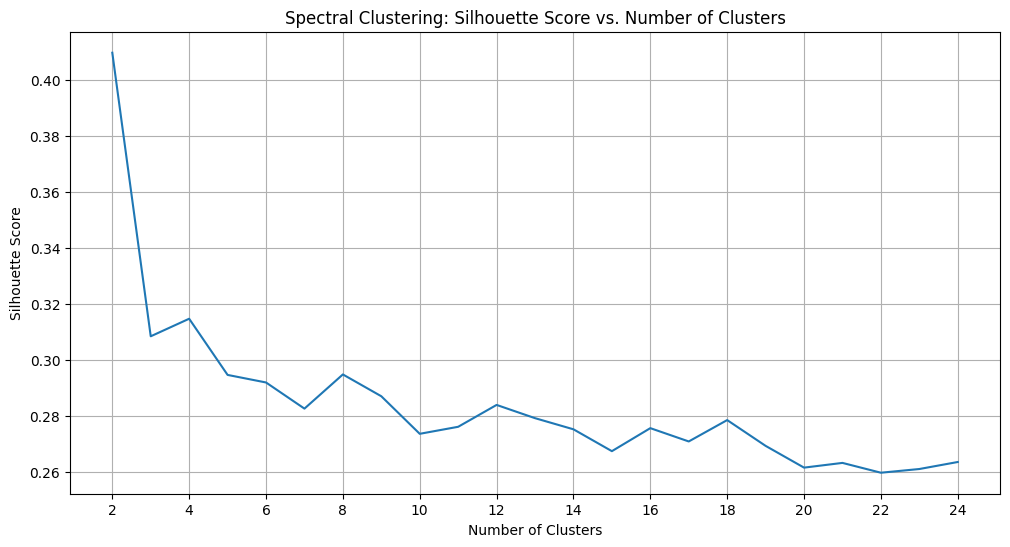

In [14]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='n_clusters', y='Silhouette_Score', data=spectral_results_df)
plt.title('Spectral Clustering: Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_n_clusters, 2))
plt.grid(True)
plt.show()

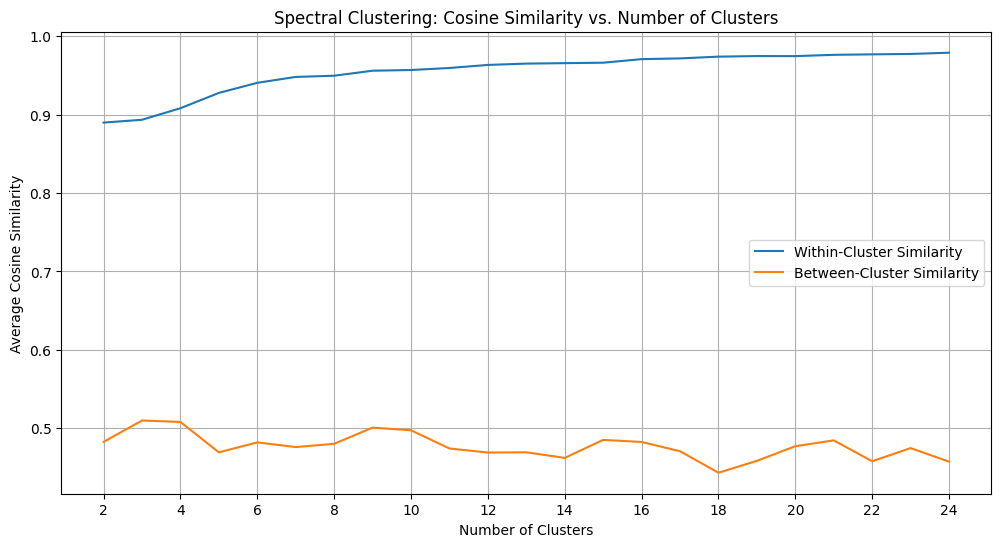

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='n_clusters', y='within_cluster_similarity', data=spectral_results_df, label='Within-Cluster Similarity')
sns.lineplot(x='n_clusters', y='between_cluster_similarity', data=spectral_results_df, label='Between-Cluster Similarity')
plt.title('Spectral Clustering: Cosine Similarity vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Cosine Similarity')
plt.xticks(range(2, max_n_clusters, 2))
plt.grid(True)
plt.legend()
plt.show()

In [16]:
#GMM

gmm_results = []
max_n_clusters = 25

for n_components in range(2, max_n_clusters):
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(df) # Fit GMM to the DataFrame
    labels = gmm.predict(df) # Predict cluster labels

    # Calculate metrics
    aic = gmm.aic(df)
    bic = gmm.bic(df)

    # Silhouette score requires at least 2 clusters and more than 1 sample per cluster
    silhouette = -1 # Default to -1 if calculation is not possible
    if len(np.unique(labels)) > 1 and df.shape[0] > len(np.unique(labels)):
        try:
            silhouette = silhouette_score(df, labels)
        except ValueError:
            silhouette = -1

    within_sim = calculate_cosine_within_cluster_similarity(df.values, labels)
    between_sim = calculate_cosine_between_cluster_similarity(df.values, labels)

    gmm_results.append({
        'n_clusters': n_components,
        'AIC': aic,
        'BIC': bic,
        'Silhouette_Score': silhouette,
        'within_cluster_similarity': within_sim,
        'between_cluster_similarity': between_sim
    })

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.head())


,n_clusters,AIC,BIC,Silhouette_Score,within_cluster_similarity,between_cluster_similarity
0,2,-8.307787e+08,-2.350500e+08,0.112409,0.785494,0.912076
1,3,-7.471308e+08,1.464623e+08,0.022360,0.820801,0.775475
2,4,-6.635606e+08,5.278969e+08,-0.043985,0.811548,0.805438
3,5,-5.799251e+08,9.093968e+08,-0.054670,0.800032,0.869654
4,6,-4.962721e+08,1.290914e+09,-0.067764,0.808276,0.865647


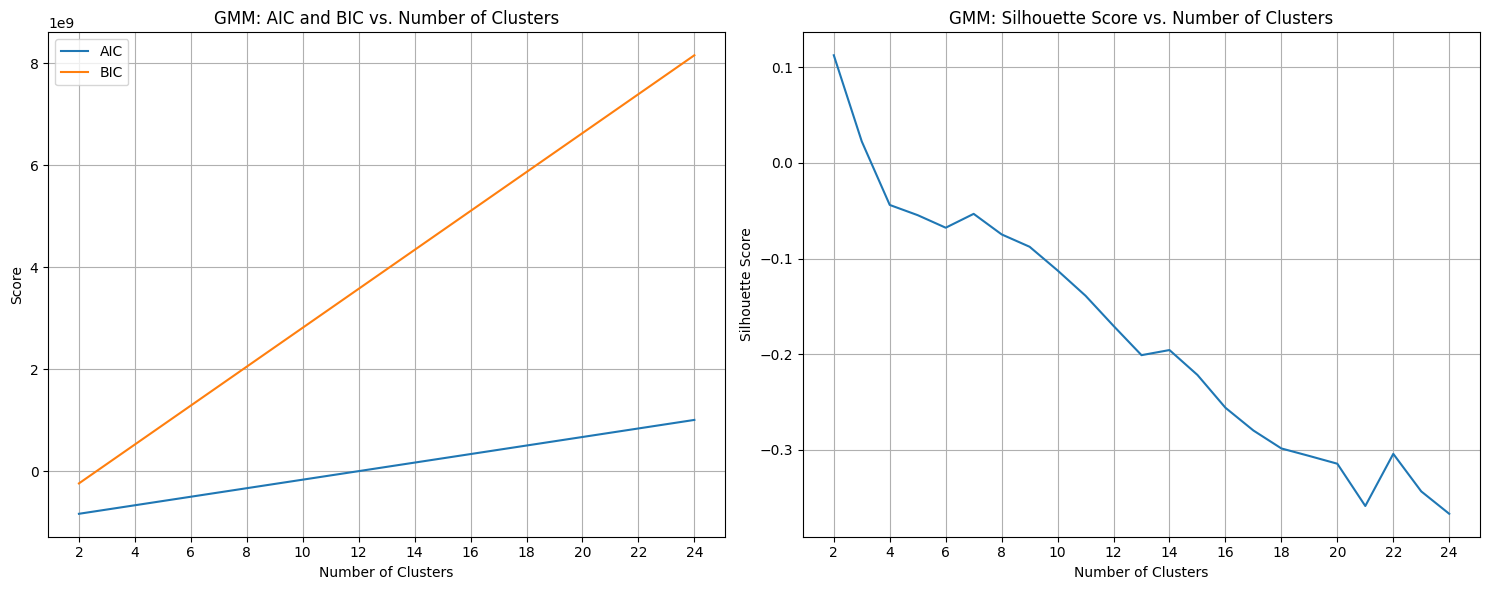

In [17]:
plt.figure(figsize=(15, 6))

# Plot AIC and BIC
plt.subplot(1, 2, 1)
sns.lineplot(x='n_clusters', y='AIC', data=gmm_results_df, label='AIC')
sns.lineplot(x='n_clusters', y='BIC', data=gmm_results_df, label='BIC')
plt.title('GMM: AIC and BIC vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.xticks(range(2, max_n_clusters, 2))
plt.grid(True)
plt.legend()

# Plot Silhouette Score
plt.subplot(1, 2, 2)
sns.lineplot(x='n_clusters', y='Silhouette_Score', data=gmm_results_df)
plt.title('GMM: Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_n_clusters, 2))
plt.grid(True)

plt.tight_layout()
plt.show()

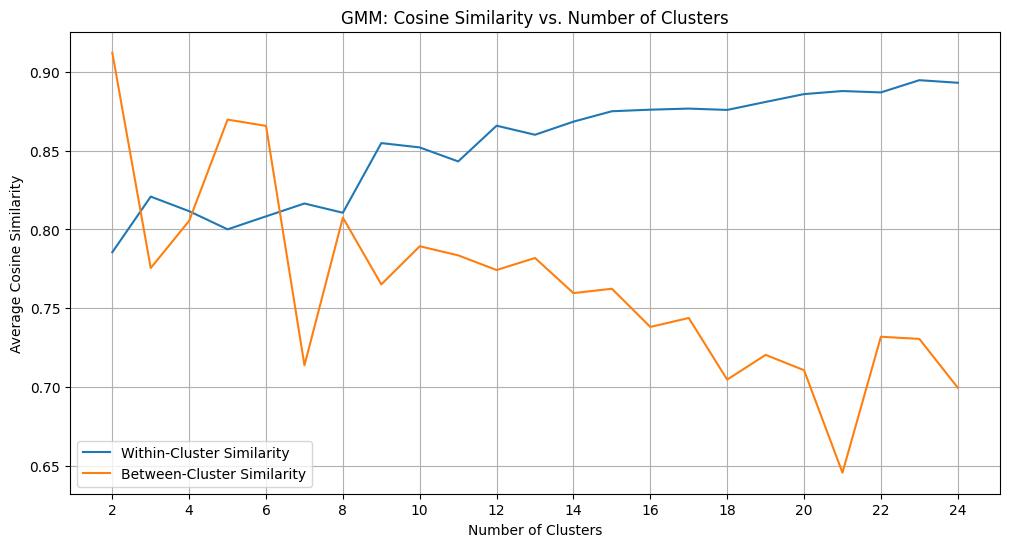

In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='n_clusters', y='within_cluster_similarity', data=gmm_results_df, label='Within-Cluster Similarity')
sns.lineplot(x='n_clusters', y='between_cluster_similarity', data=gmm_results_df, label='Between-Cluster Similarity')
plt.title('GMM: Cosine Similarity vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Cosine Similarity')
plt.xticks(range(2, max_n_clusters, 2))
plt.grid(True)
plt.legend()
plt.show()

In [20]:
#get clusters for spectral, with 8 clusters
n_clusters_spectral = 8
spectral_final = SpectralClustering(n_clusters=n_clusters_spectral, assign_labels='kmeans', random_state=42, affinity='nearest_neighbors')
df['spectral_cluster_labels_8'] = spectral_final.fit_predict(df)

print(f"Spectral Clustering applied with {n_clusters_spectral} clusters.")
display(df.head())


/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/sklearn/cluster/_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(


Spectral Clustering applied with 8 clusters.


,0,1,2,3,4,5,6,7,8,9,...,9136,9137,9138,9139,9140,9141,9142,9143,9144,spectral_cluster_labels_8
0,3.516703,3.409540,3.072912,0.527976,3.034622,2.831076,2.075563,1.840887,2.084241,1.373931,...,1.255023,1.268221,1.336127,0.825495,1.618738,0.813058,1.874163,5.366706,2.702283,1
1,3.614934,3.070338,3.133250,0.394827,3.060764,2.543756,2.101262,1.292691,2.233731,1.243716,...,1.362504,1.521192,1.243997,0.938525,1.741289,0.784720,1.152420,5.394567,2.956477,1
2,3.108233,2.989193,2.715768,0.178095,2.704708,2.539902,1.795120,1.351725,1.776713,1.001231,...,0.712826,0.903910,0.908437,0.513998,1.100584,0.111875,1.569019,4.963816,2.243116,1
3,0.829676,0.585189,0.276683,2.636544,0.187466,1.597532,0.544271,3.667013,0.561779,0.975897,...,2.902367,-2.632039,1.561512,0.118954,0.793149,3.275426,6.833592,-1.223650,0.353522,7
4,3.608739,3.433020,3.179860,0.141867,3.130227,2.781789,2.099485,1.418330,2.093578,1.249201,...,0.859712,1.606587,1.037678,0.746984,1.435214,0.277455,1.082236,5.672187,2.762363,1


In [21]:
#get clusters for spectral, with 8 clusters
n_clusters_spectral = 8
spectral_final = SpectralClustering(n_clusters=n_clusters_spectral, assign_labels='kmeans', random_state=42, affinity='nearest_neighbors')
df3['spectral_cluster_labels_8'] = spectral_final.fit_predict(df3)

print(f"Spectral Clustering applied with {n_clusters_spectral} clusters.")
display(df3.head())

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/sklearn/cluster/_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(


Spectral Clustering applied with 8 clusters.


,HopX1a_N-terminal_1_88,HopX1a_C-terminal_298_380,HopX1c_N-terminal_1_87,HopX1c_Middle_212_267,HopX1b_N-terminal_1_74,HopX1g_N-terminal_1_68,HopBO1c_N-terminal_1_57,HopBO1c_Middle_112_205,HopBO1b_N-terminal_1_59,HopBO1b_Middle_105_171,...,Q944Q0_middle_425_509,Q94AU3_N-terminal_1_65,Q9ATB4_middle_181_246,Q9ATB4_middle_365_416,Q9C6K4_N-terminal_1_82,Q9C6K4_middle_209_305,Q9C9I4_N-terminal_1_56,Q9LF48_C-terminal_101_175,Q9LXF4_N-terminal_1_79,spectral_cluster_labels_8
HopX1a_N-terminal_1_88,3.516703,3.409540,3.072912,0.527976,3.034622,2.831076,2.075563,1.840887,2.084241,1.373931,...,1.255023,1.268221,1.336127,0.825495,1.618738,0.813058,1.874163,5.366706,2.702283,1
HopX1a_C-terminal_298_380,3.614934,3.070338,3.133250,0.394827,3.060764,2.543756,2.101262,1.292691,2.233731,1.243716,...,1.362504,1.521192,1.243997,0.938525,1.741289,0.784720,1.152420,5.394567,2.956477,1
HopX1c_N-terminal_1_87,3.108233,2.989193,2.715768,0.178095,2.704708,2.539902,1.795120,1.351725,1.776713,1.001231,...,0.712826,0.903910,0.908437,0.513998,1.100584,0.111875,1.569019,4.963816,2.243116,1
HopX1c_Middle_212_267,0.829676,0.585189,0.276683,2.636544,0.187466,1.597532,0.544271,3.667013,0.561779,0.975897,...,2.902367,-2.632039,1.561512,0.118954,0.793149,3.275426,6.833592,-1.223650,0.353522,7
HopX1b_N-terminal_1_74,3.608739,3.433020,3.179860,0.141867,3.130227,2.781789,2.099485,1.418330,2.093578,1.249201,...,0.859712,1.606587,1.037678,0.746984,1.435214,0.277455,1.082236,5.672187,2.762363,1


In [23]:
# Combine df3 index (original names) with the new cluster labels
clustered_names_df3 = pd.DataFrame({
    'original_name': df3.index,
    'spectral_cluster_label': df3['spectral_cluster_labels_8']
})

# Display names for each cluster
#print("\nNames within each Spectral Cluster (8 clusters from df3):")
#for cluster_id in sorted(clustered_names_df3['spectral_cluster_label'].unique()):
    #names_in_cluster = clustered_names_df3[clustered_names_df3['spectral_cluster_label'] == cluster_id]['original_name'].tolist()
    #print(f"Cluster {cluster_id}: {', '.join(names_in_cluster)}")

In [24]:
display(clustered_names_df3.head())

,original_name,spectral_cluster_label
HopX1a_N-terminal_1_88,HopX1a_N-terminal_1_88,1
HopX1a_C-terminal_298_380,HopX1a_C-terminal_298_380,1
HopX1c_N-terminal_1_87,HopX1c_N-terminal_1_87,1
HopX1c_Middle_212_267,HopX1c_Middle_212_267,7
HopX1b_N-terminal_1_74,HopX1b_N-terminal_1_74,1


In [25]:
# Extract 'name' (before the first underscore) and 'type' (between the first and second underscore)
clustered_names_df3['name'] = clustered_names_df3['original_name'].apply(lambda x: x.split('_')[0])
clustered_names_df3['type'] = clustered_names_df3['original_name'].apply(lambda x: x.split('_')[1])

# Display the updated DataFrame with the new columns
display(clustered_names_df3.head())

,original_name,spectral_cluster_label,name,type
HopX1a_N-terminal_1_88,HopX1a_N-terminal_1_88,1,HopX1a,N-terminal
HopX1a_C-terminal_298_380,HopX1a_C-terminal_298_380,1,HopX1a,C-terminal
HopX1c_N-terminal_1_87,HopX1c_N-terminal_1_87,1,HopX1c,N-terminal
HopX1c_Middle_212_267,HopX1c_Middle_212_267,7,HopX1c,Middle
HopX1b_N-terminal_1_74,HopX1b_N-terminal_1_74,1,HopX1b,N-terminal


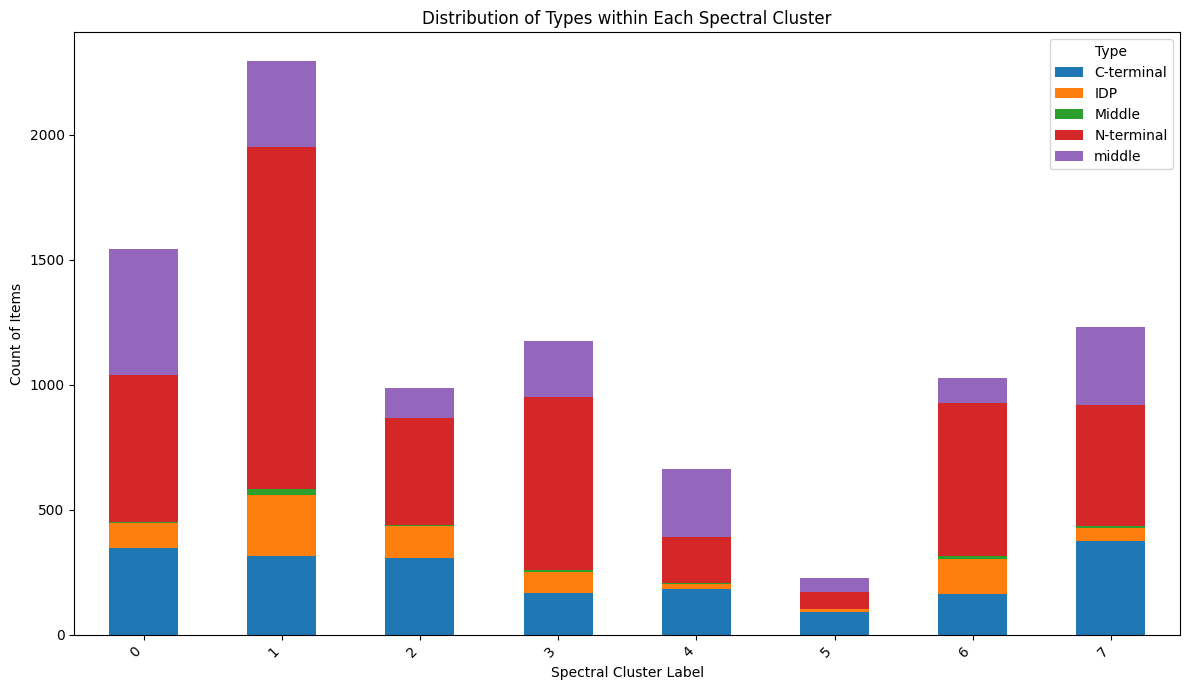

In [26]:
# Group by cluster label and type, then count occurrences
cluster_type_counts = clustered_names_df3.groupby(['spectral_cluster_label', 'type']).size().unstack(fill_value=0)

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))
cluster_type_counts.plot(kind='bar', stacked=True, ax=ax)

plt.title('Distribution of Types within Each Spectral Cluster')
plt.xlabel('Spectral Cluster Label')
plt.ylabel('Count of Items')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

In [27]:
clustered_names_df3['category'] = np.where(np.arange(len(clustered_names_df3)) < 256, 'effector', 'plant')
display(clustered_names_df3.head())

,original_name,spectral_cluster_label,name,type,category
HopX1a_N-terminal_1_88,HopX1a_N-terminal_1_88,1,HopX1a,N-terminal,effector
HopX1a_C-terminal_298_380,HopX1a_C-terminal_298_380,1,HopX1a,C-terminal,effector
HopX1c_N-terminal_1_87,HopX1c_N-terminal_1_87,1,HopX1c,N-terminal,effector
HopX1c_Middle_212_267,HopX1c_Middle_212_267,7,HopX1c,Middle,effector
HopX1b_N-terminal_1_74,HopX1b_N-terminal_1_74,1,HopX1b,N-terminal,effector


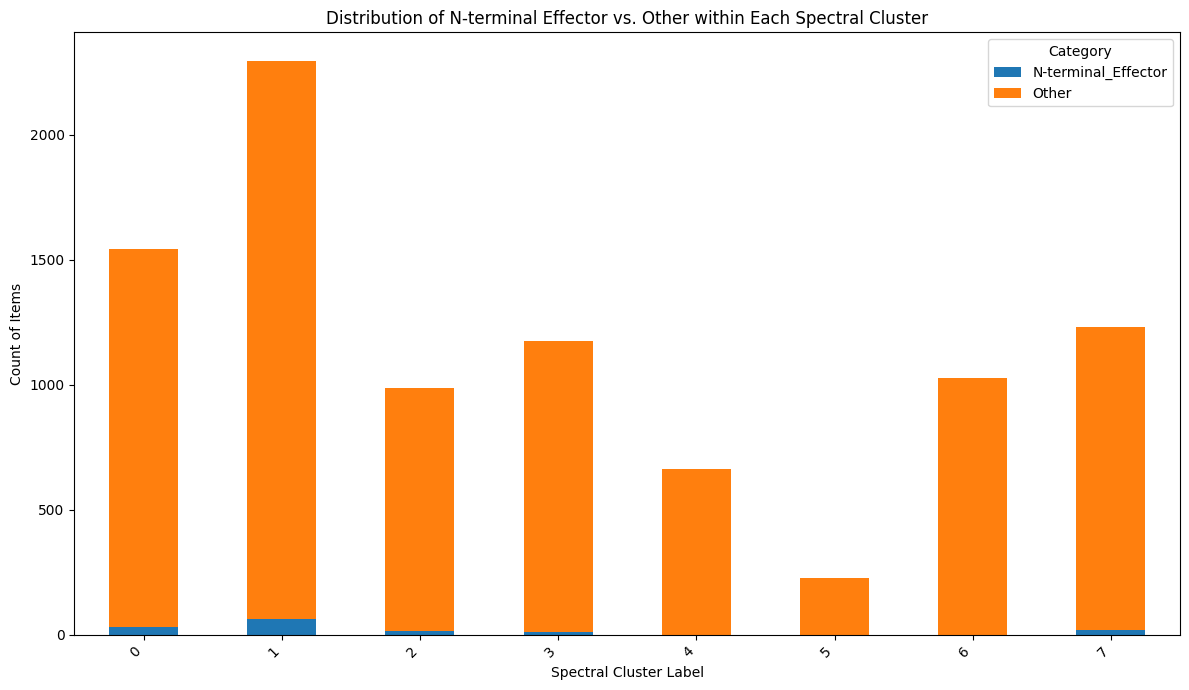

In [28]:
# Create a combined category column to distinguish 'N-terminal effector' from 'Other'
clustered_names_df3['N-terminal_Effector_vs_Other'] = np.where(
    (clustered_names_df3['type'] == 'N-terminal') &
    (clustered_names_df3['category'] == 'effector'),
    'N-terminal_Effector',
    'Other'
)

# Group by cluster label and the new combined category, then count occurrences
cluster_combined_counts = clustered_names_df3.groupby(['spectral_cluster_label', 'N-terminal_Effector_vs_Other']).size().unstack(fill_value=0)

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))
cluster_combined_counts.plot(kind='bar', stacked=True, ax=ax)

plt.title('Distribution of N-terminal Effector vs. Other within Each Spectral Cluster')
plt.xlabel('Spectral Cluster Label')
plt.ylabel('Count of Items')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

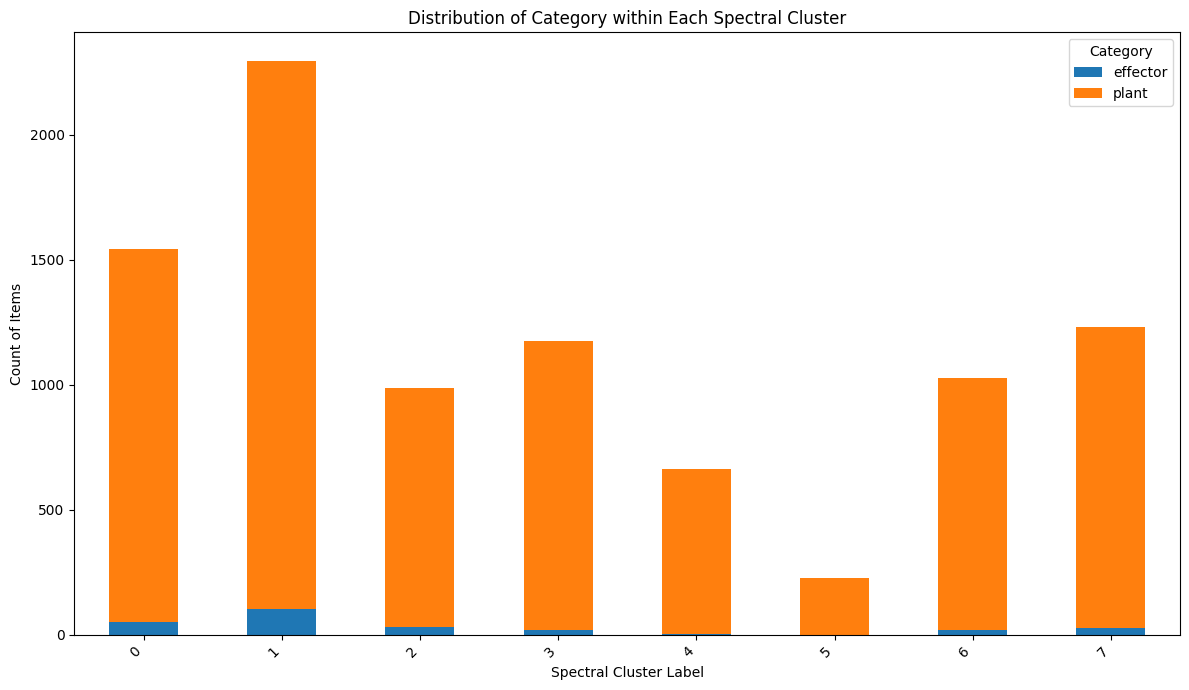

In [29]:
# Group by cluster label and category, then count occurrences
cluster_category_counts = clustered_names_df3.groupby(['spectral_cluster_label', 'category']).size().unstack(fill_value=0)

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))
cluster_category_counts.plot(kind='bar', stacked=True, ax=ax)

plt.title('Distribution of Category within Each Spectral Cluster')
plt.xlabel('Spectral Cluster Label')
plt.ylabel('Count of Items')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

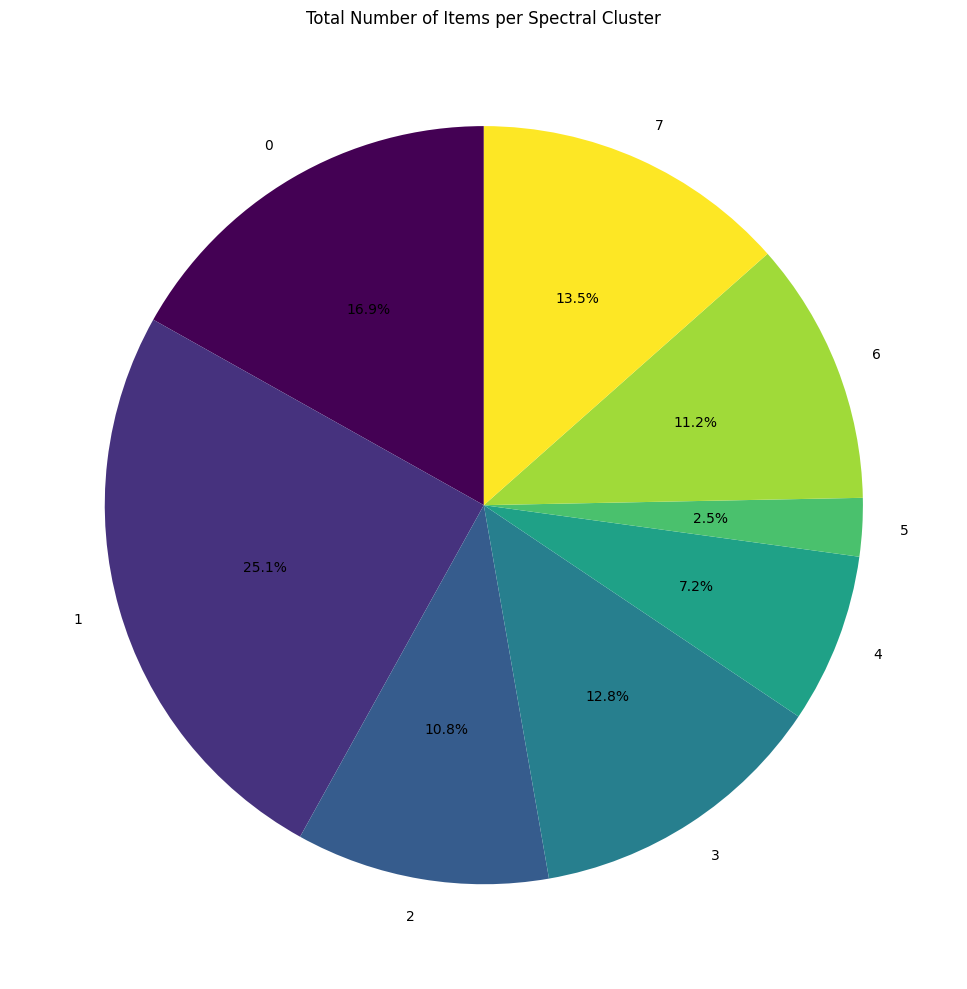

In [30]:
# Calculate the total number of items in each cluster
cluster_counts = clustered_names_df3['spectral_cluster_label'].value_counts().sort_index()

# Create the pie chart
fig, ax = plt.subplots(figsize=(10, 10))
cluster_counts.plot.pie(autopct='%1.1f%%', startangle=90, ax=ax, cmap='viridis')

plt.title('Total Number of Items per Spectral Cluster')
plt.ylabel('') # Hide the default y-label for pie charts
plt.tight_layout()
plt.show()

In [36]:
for cluster_id in sorted(clustered_names_df3['spectral_cluster_label'].unique()):
    # Filter names for the current cluster
    names_in_cluster = clustered_names_df3[clustered_names_df3['spectral_cluster_label'] == cluster_id]['name'].tolist()

    # Remove whitespace from each name and join with a comma
    processed_names = [name.replace(' ', '') for name in names_in_cluster]
    output_line = ', '.join(processed_names)

    # Define the filename for the current cluster
    filename = f'/home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_{cluster_id}_names_line.txt'

    # Write the processed names to the file
    with open(filename, 'w') as f:
        f.write(output_line)

    print(f"Names for Cluster {cluster_id} saved to {filename}")

Names for Cluster 0 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_0_names_line.txt
Names for Cluster 1 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_1_names_line.txt
Names for Cluster 2 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_2_names_line.txt
Names for Cluster 3 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_3_names_line.txt
Names for Cluster 4 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_4_names_line.txt
Names for Cluster 5 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_5_names_line.txt
Names for Cluster 6 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_6_names_line.txt
Names for Cluster 7 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_7_names_line.txt


In [34]:
for cluster_id in sorted(clustered_names_df3['spectral_cluster_label'].unique()):
    # Filter 'name' for the current cluster
    names_in_cluster = clustered_names_df3[clustered_names_df3['spectral_cluster_label'] == cluster_id]['name'].tolist()

    # Remove whitespace from each name and join with a newline
    processed_names = [name.replace(' ', '') for name in names_in_cluster]
    output_line = '\n'.join(processed_names)
    
    # Define the filename for the current cluster
    filename = f'/home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_{cluster_id}_names.txt'

    # Write the processed names to the file
    with open(filename, 'w') as f:
        f.write(output_line)

    print(f"Names for Cluster {cluster_id} saved to {filename}")

Names for Cluster 0 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_0_names.txt
Names for Cluster 1 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_1_names.txt
Names for Cluster 2 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_2_names.txt
Names for Cluster 3 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_3_names.txt
Names for Cluster 4 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_4_names.txt
Names for Cluster 5 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_5_names.txt
Names for Cluster 6 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_6_names.txt
Names for Cluster 7 saved to /home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_7_names.txt


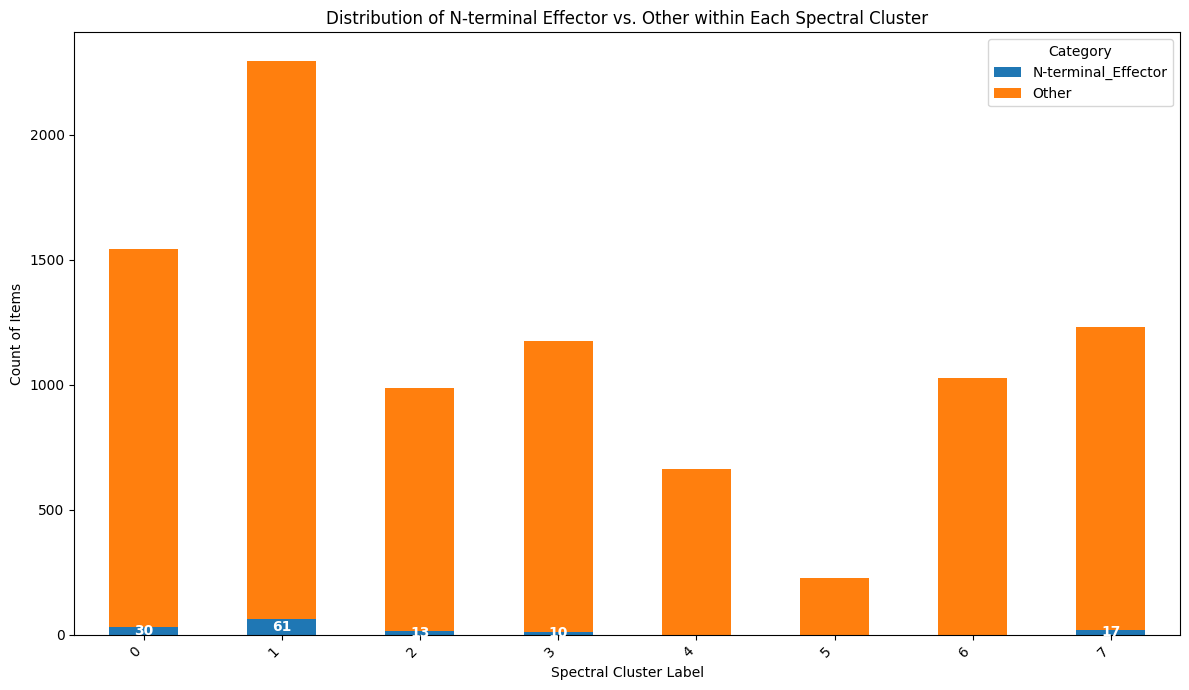

In [35]:
# Create a combined category column to distinguish 'N-terminal effector' from 'Other'
clustered_names_df3['N-terminal_Effector_vs_Other'] = np.where(
    (clustered_names_df3['type'] == 'N-terminal') &
    (clustered_names_df3['category'] == 'effector'),
    'N-terminal_Effector',
    'Other'
)

# Group by cluster label and the new combined category, then count occurrences
cluster_combined_counts = clustered_names_df3.groupby(['spectral_cluster_label', 'N-terminal_Effector_vs_Other']).size().unstack(fill_value=0)

# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))
cluster_combined_counts.plot(kind='bar', stacked=True, ax=ax)

plt.title('Distribution of N-terminal Effector vs. Other within Each Spectral Cluster')
plt.xlabel('Spectral Cluster Label')
plt.ylabel('Count of Items')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category')

# Add the count of 'N-terminal_Effector' on top of the bars
for container in ax.containers:
    # Only annotate the 'N-terminal_Effector' part if it exists
    if 'N-terminal_Effector' in cluster_combined_counts.columns and container.get_label() == 'N-terminal_Effector':
        for i, patch in enumerate(container.patches):
            height = patch.get_height()
            if height > 0:
                ax.text(patch.get_x() + patch.get_width() / 2.,
                        patch.get_y() + height / 2.,
                        int(height),
                        ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [37]:
# Filter for N-terminal effectors
effector_n_terminal_names = clustered_names_df3[
    (clustered_names_df3['type'] == 'N-terminal') &
    (clustered_names_df3['category'] == 'effector')
]

print("N-terminal Effector names within each Spectral Cluster:")
for cluster_id in sorted(effector_n_terminal_names['spectral_cluster_label'].unique()):
    names_in_cluster = effector_n_terminal_names[effector_n_terminal_names['spectral_cluster_label'] == cluster_id]['name'].tolist()
    if names_in_cluster:
        print(f"Cluster {cluster_id}: {', '.join(names_in_cluster)}")
    else:
        print(f"Cluster {cluster_id}: No N-terminal effectors found")

N-terminal Effector names within each Spectral Cluster:
Cluster 0: HopX1g, HopD1a, HopAR1f, HopBD1d, HopBD1j, HopR1f, HopR1c, HopR1g, HopAU1a, HopAL1b, HopM1v, HopM1d, HopM1b, HopM1t, HopM1h, HopM1n, HopM1j, HopV1j, HopV1k, HopV1o, HopV1g, HopV1d, HopV1n, AvrE1o, HopA1m, HopAB1m, HopBD1c, HopM1ae, HopM1l, HopV1a
Cluster 1: HopX1a, HopX1c, HopX1b, HopBO1c, HopBO1b, HopBO1a, HopBO1d, AvrRpm1e, AvrRpm1i, HopO1h, HopG1a, HopG1c, HopZ1g, AvrB2c, AvrB2e, AvrB2d, AvrB2a, HopK1d, HopAQ1a, HopW1i, HopW1m, HopW1j, HopW1t, HopAF1a, HopAF1b, HopR1a, HopR1b, HopBJ1b, HopF1q, HopZ1d, HopF1p, HopF3a, HopF1k, HopO1c, HopO1b, HopO1d, HopM1s, HopM1af, HopM1y, HopM1g, HopM1x, HopM1r, HopM1f, HopV1b, AvrRpm1c, HopAB1l, HopAG1j, HopAG1p, HopAH1t, HopBD1e, HopBP1e, HopF1v, HopG1g, HopM1aa, HopM1ab, HopM1ad, HopR1d, HopR1e, HopR1h, HopW1r, HopW1u
Cluster 2: HopAB1a, HopAB1n, HopBL1b, HopAT1c, HopAT1g, HopAT1m, HopAT1i, HopW1h, HopW1f, HopAF1n, HopAG1b, HopZ2b, AvrPto1n
Cluster 3: HopG1b, HopQ1b, HopQ1a, HopA

In [40]:
#load in just the Arabidopsis Data set
df_ward = pd.read_csv("/home/wenyuantong/Desktop/data/arabi_cross/50_100_Ward_reordered.csv", index_col=0)
df_ward.head()

,6836,8166,8363,4495,9054,6130,7126,2316,7143,5853,...,2051,8494,8972,6816,4469,2629,2674,8061,4531,5090
6836,120.721380,96.939343,82.638337,94.455906,89.253130,89.737834,75.484151,72.084802,70.876350,67.208997,...,-28.901363,-31.136825,-31.993023,-33.405025,-34.871755,-35.291929,-32.757192,-31.596042,-32.590829,-39.663716
6130,108.489023,87.550436,74.869788,85.273591,80.696100,80.808053,68.125191,65.044603,63.988310,60.718105,...,-26.071296,-28.447613,-28.748457,-30.238747,-31.550582,-32.074107,-30.115746,-29.327219,-30.412429,-36.926388
4495,99.362706,80.647765,68.862461,78.251087,74.141332,74.199098,62.875421,59.896892,58.979545,55.946028,...,-23.152199,-25.242896,-25.597602,-26.874812,-28.052937,-28.424362,-26.675927,-25.891111,-26.893000,-32.597555
7381,79.213715,63.952748,54.408000,62.050781,58.458388,58.914406,49.232265,47.105113,45.846559,43.713864,...,-20.111065,-21.332476,-22.641079,-23.251257,-24.015906,-24.607011,-22.961730,-22.175767,-22.732790,-27.641694
2334,85.414636,69.327205,59.053990,67.216699,63.532344,63.902610,53.946135,51.359468,50.272422,47.905170,...,-20.987051,-22.392800,-23.371202,-23.931716,-24.862440,-25.465049,-23.639184,-23.102693,-23.851960,-29.068268


In [41]:
def calculate_average_pairwise_cosine_within_cluster_similarity(data_matrix, labels):
    """
    Calculates the average pairwise within-cluster cosine similarity.
    Similarity is calculated between all unique pairs of points within each cluster.
    """
    unique_labels = np.unique(labels)
    within_similarities = []

    for label in unique_labels:
        cluster_points = data_matrix[labels == label]
        N = cluster_points.shape[0]

        if N > 1:
            # Calculate pairwise cosine similarity for all points within the cluster
            # The resulting matrix will have 1s on the diagonal (self-similarity)
            pairwise_sim_matrix = cosine_similarity(cluster_points)

            # To get the average pairwise similarity excluding self-similarity:
            # Sum all similarities, subtract N (for the diagonal 1s), then divide by N * (N - 1)
            # (N*(N-1) is the number of unique pairs in both directions)
            sum_of_all_similarities = pairwise_sim_matrix.sum()
            avg_pairwise_sim = (sum_of_all_similarities - N) / (N * (N - 1))
            within_similarities.append(avg_pairwise_sim)
        elif N == 1:
            # A single-point cluster is considered perfectly cohesive internally
            within_similarities.append(1.0)

    if len(within_similarities) > 0:
        return np.mean(within_similarities)
    return 0.0

In [42]:
# Perform Ward hierarchical clustering to get the linkage matrix (Z is already defined from previous run)
# Z = linkage(df, method='ward')
Z = row_linkage

results_pairwise = []
for n_clusters in range(2, 25):
    # Get cluster labels for the current number of clusters
    labels = fcluster(Z, n_clusters, criterion='maxclust')

    # Calculate similarities using the new pairwise function
    within_sim_pairwise = calculate_average_pairwise_cosine_within_cluster_similarity(df_ward.values, labels)
    between_sim = calculate_cosine_between_cluster_similarity(df_ward.values, labels) # Between-cluster remains centroid-based

    results_pairwise.append({
        'n_clusters': n_clusters,
        'within_cluster_similarity': within_sim_pairwise,
        'between_cluster_similarity': between_sim
    })

# Convert results to a DataFrame for easier analysis and display
results_df_pairwise = pd.DataFrame(results_pairwise)
display(results_df_pairwise.head())

NameError: name 'row_linkage' is not defined

In [43]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='n_clusters', y='within_cluster_similarity', data=df_ward, label='Within-Cluster Similarity')
sns.lineplot(x='n_clusters', y='between_cluster_similarity', data=df_ward, label='Between-Cluster Similarity')
plt.title('Cosine Similarity vs. Number of Clusters (Ward Clustering)')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Cosine Similarity')
plt.xticks(range(2, 25, 2))
plt.grid(True)
plt.legend()
plt.show()

ValueError: Could not interpret value `n_clusters` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='n_clusters', y='within_cluster_similarity', data=results_df_pairwise, label='Within-Cluster (Pairwise) Similarity')
sns.lineplot(x='n_clusters', y='between_cluster_similarity', data=results_df_pairwise, label='Between-Cluster (Centroid) Similarity')
plt.title('Ward Clustering: Cosine Similarity vs. Number of Clusters (Pairwise Within-Cluster)')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Cosine Similarity')
plt.xticks(range(2, 25, 2))
plt.grid(True)
plt.legend()
plt.show()